# $\text{Taller - Redes Neuronales Artificiales: Clasificación de Textos}$

##$\text{Clasificación de Textos Religiosos con Redes Neuronales}$

---

##$\text{Tabla de Contenido}$

1. $\text{Importar Librerías}$
2. $\text{Introducción a Redes Neuronales}$
    - $\text{¿Qué es una ANN?}$
    - $\text{Componentes principales de una ANN}$
3. $\text{Comprendiendo los Datos}$
    - $\text{Descripción del Dataset}$
    - $\text{Carga y Exploración de Datos}$
    - $\text{Limpieza y Preprocesamiento de Datos}$
4. $\text{Entrenamiento de un Modelo ANN}$
    - $\text{Preparación de Datos para Entrenamiento}$
    - $\text{Definición del Modelo}$
    - $\text{Entrenamiento y Validación}$
5. $\text{Evaluación y Visualización}$
    - $\text{Métricas de Rendimiento}$
    - $\text{Visualización de Resultados}$
6. $\text{Conclusiones}$

## 1. $\text{Importar Librerías}$

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import tensorflow as tf

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 5)

### Función RealTimePlotCallback

In [ ]:
class RealTimePlotCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2)
        plt.close(self.fig)  # Evitar duplicados
        self.epochs = []
        self.loss = []
        self.val_loss = []
        self.acc = []
        self.val_acc = []

    def on_epoch_end(self, epoch, logs=None):
        # Actualizar métricas
        self.epochs.append(epoch + 1)
        self.loss.append(logs["loss"])
        self.val_loss.append(logs["val_loss"])
        self.acc.append(logs["accuracy"])
        self.val_acc.append(logs["val_accuracy"])

        # Limpiar y redibujar
        display.clear_output(wait=True)
        self.fig, (self.ax1, self.ax2) = plt.subplots(1, 2)

        # Gráfica de Precisión
        self.ax1.plot(self.epochs, self.acc, "b-", label="Entrenamiento")
        self.ax1.plot(self.epochs, self.val_acc, "r-", label="Validación")
        self.ax1.set_title("Precisión por Época", fontsize = 24, fontweight='bold')
        self.ax1.set_xlabel("Época", fontsize = 18, fontweight='bold')
        self.ax1.legend()

        # Gráfica de Pérdida
        self.ax2.plot(self.epochs, self.loss, "b-", label="Entrenamiento")
        self.ax2.plot(self.epochs, self.val_loss, "r-", label="Validación")
        self.ax2.set_title("Pérdida por Época", fontsize = 24, fontweight='bold')
        self.ax2.set_xlabel("Época", fontsize = 18, fontweight='bold')
        self.ax2.legend()

        plt.tight_layout()
        plt.show()

## 2. $\text{Introducción a Redes Neuronales}$

**¿Qué es una ANN?**

Una red neuronal artificial (ANN) es un modelo inspirado en la estructura del cerebro humano. Está formada por neuronas artificiales interconectadas que aprenden patrones complejos a partir de los datos.

### Componentes principales de una ANN:

1. **Capas de Entrada:** Donde ingresan las características del dataset.
2. **Capas Ocultas:** Realizan cálculos mediante funciones de activación no lineales.
3. **Capa de Salida:** Genera las predicciones finales según la tarea (por ejemplo, clasificación o regresión).
4. **Funciones de Activación:** Controlan cómo se propagan los datos entre capas.

---


## 3. $\text{Comprendiendo los Datos}$


### **Descripción del Dataset**:

Este dataset contiene una matriz de término-documento (DTM) con frecuencias de palabras extraídas de textos religiosos asiáticos y bíblicos. La tarea es clasificar cada texto en su respectiva categoría usando las frecuencias de palabras como características.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Cargar y explorar el dataset

In [ ]:
# Cargue el dataset: AllBooks_baseline_DTM_Labelled.csv

In [ ]:
data_book = pd.read_csv('/content/drive/MyDrive/UNAL/Semestre III/ML/Datas/AllBooks_baseline_DTM_Labelled.csv')

In [ ]:
# Imprima las primeras 5 filas
data_book.head()

,Unnamed: 0,foolishness,hath,wholesome,takest,feelings,anger,vaivaswata,matrix,kindled,...,erred,thinkest,modern,reigned,sparingly,visual,thoughts,illumines,attire,explains
0,Buddhism_Ch1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Buddhism_Ch2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Buddhism_Ch3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,Buddhism_Ch4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Buddhism_Ch5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Limpieza

In [ ]:
# Extraer las etiquetas (ej: "Buddhism" de "Buddhism_Ch1")
data_book['label'] = data_book['Unnamed: 0'].apply(lambda x: x.split('_')[0])

In [ ]:
# Eliminar columna no necesaria
data = data_book.drop('Unnamed: 0', axis=1)

In [ ]:
data.head()

,foolishness,hath,wholesome,takest,feelings,anger,vaivaswata,matrix,kindled,convict,...,thinkest,modern,reigned,sparingly,visual,thoughts,illumines,attire,explains,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Buddhism
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Buddhism
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Buddhism
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Buddhism
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Buddhism


### Gráfico Countplot

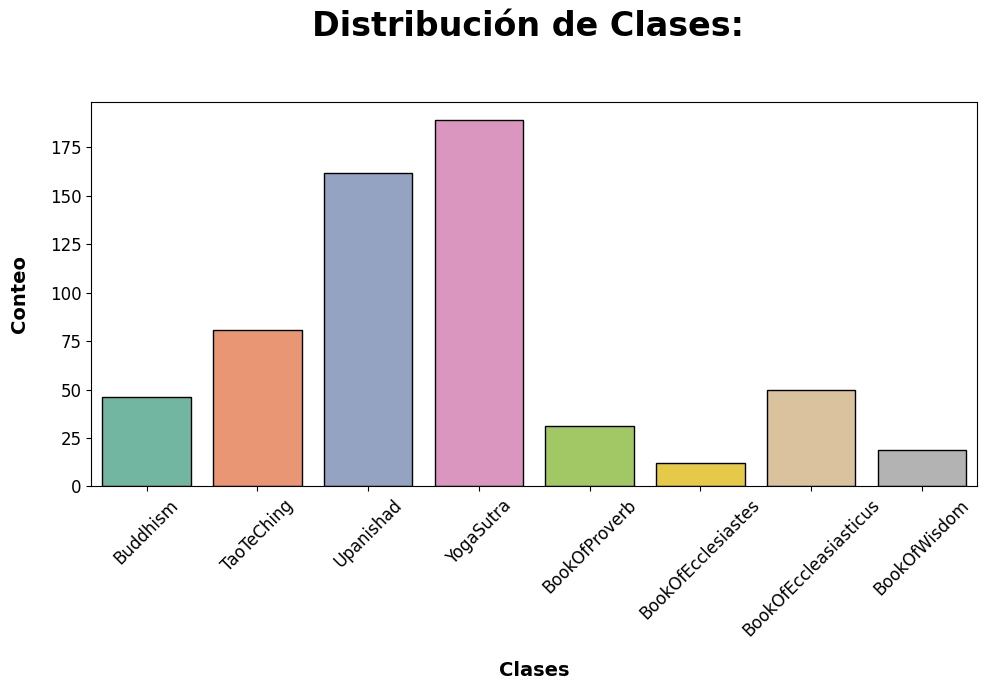

In [ ]:
# Ver distribución de clases de las etiquetasa extraídas
plt.figure(figsize=(10, 7))
sns.countplot(x='label', data=data, hue = 'label',  palette = 'Set2', edgecolor='black')
plt.xticks(rotation=45)
# Estilizar título y ejes
plt.title('Distribución de Clases: \n', fontsize=24, fontweight='bold', pad=20)
plt.xlabel('Clases', fontsize=14, fontweight='bold', labelpad=15)
plt.ylabel('Conteo', fontsize=14, fontweight='bold', labelpad=15)
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)
# Mostrar gráfico
plt.tight_layout()
plt.show()

## 4. $\text{Entrenamiento de un Modelo ANN}$

### Preparación de Datos para Entrenamiento

In [ ]:
# Codificar etiquetas a números
le = LabelEncoder()
labels = le.fit_transform(data['label'])

# Separar features (X) y target (y)
X = data.drop('label', axis=1).values  # Matriz de frecuencias de palabras
y = labels

# Normalizar los datos (importante para ANN)
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Convertir etiquetas a one-hot encoding
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

### Definición del Modelo

In [ ]:
# Modelo más pequeño con un 65 % de accucarcy
# model = Sequential()
# model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))  # Capa oculta 1
# model.add(Dropout(0.3))  # Regularización
# model.add(Dense(64, activation='relu'))  # Capa oculta 2
# model.add(Dropout(0.2))
# model.add(Dense(len(le.classes_), activation='softmax'))  # Capa de salida para multiclase

# model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
# model.summary()

In [ ]:
# Modelo más complejo que emjora el rendiemiento
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(len(le.classes_), activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)
rt_plot = RealTimePlotCallback()  # Nuestro callback personalizado para las gráficas en tiempo real

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │       4,232,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │           1,032 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,397,960 (16.78 MB)

 Trainable params: 4,397,960 (16.78 MB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento y Validación

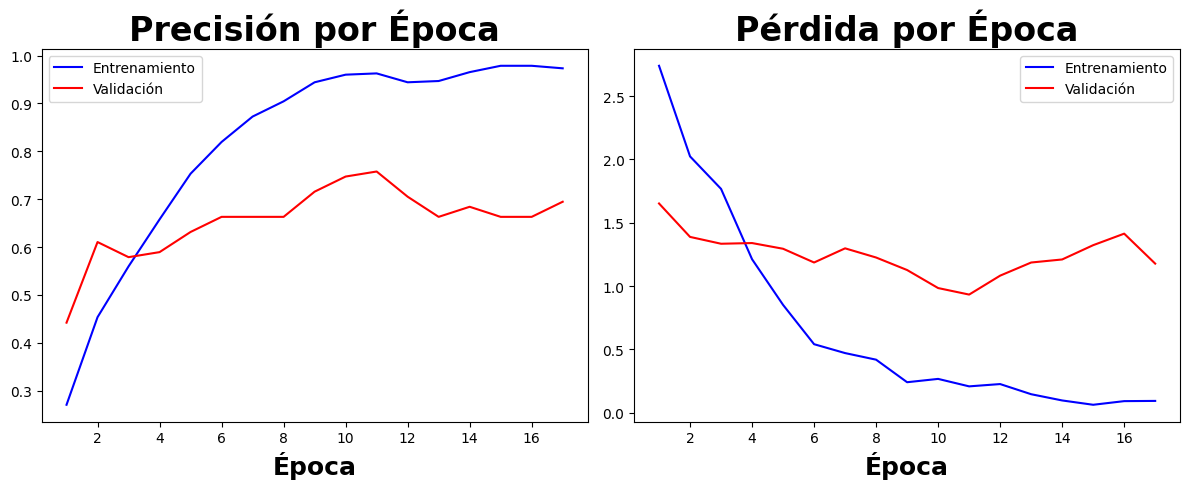

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 0.9741 - loss: 0.0834 - val_accuracy: 0.6947 - val_loss: 1.1775
Epoch 18/100
 8/12 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9657 - loss: 0.1973

In [ ]:
# --- Entrenamiento con  Early Stopping ---
history = model.fit(
    X_train, y_train_cat,
    epochs=100,  # Máximo de épocas, pero se detendrá antes con early stopping
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, rt_plot],
    verbose=1
)

## 5. $\text{Evaluación y Visualización}$

In [ ]:
# Métricas de rendimiento
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f'Precisión en prueba: {accuracy*100:.1f}%')

In [ ]:
# Reporte de clasificación
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))

In [ ]:
# Matriz de confusión
plt.figure(figsize=(9, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_classes), annot=True, fmt='d', cmap='Oranges',
            xticklabels=le.classes_, yticklabels=le.classes_,  annot_kws={"size": 16})
plt.xlabel('Predicción', fontsize=14, weight='bold', labelpad=15)
plt.ylabel('Etiqueta Real', fontsize=14, weight='bold', labelpad=15)
plt.title('Matriz de Confusión: \n', fontsize=20, weight='bold', pad=20)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

## Con categorías binarias

Como no se observa un buen tratamiento en los libros con pocas muestras haga clasificación sobre **Escrituras Asiáticas vs Biblia Hebrea**

Primero, necesitamos agrupar las clases existentes en dos categorías:

* **Escrituras Asiáticas:**

  *   `Buddhism` ,
  *   `TaoTeChing`,
  * `Upanishad`,
  * `YogaSutra`.



* **Biblia Hebrea:**
  * `BookOfEccleasiasticus`,
  * `BookOfEcclesiastes`,
  * `BookOfProverb`,
  * `BookOfWisdom`.

In [ ]:
# Crear nueva columna con etiquetas binarias
data['binary_label'] = data['label'].apply(
    lambda x: 'Escrituras Asiáticas' if x in ['Buddhism', 'TaoTeChing', 'Upanishad', 'YogaSutra']
              else 'Biblia Hebrea'
)

# Ver distribución
print(data['binary_label'].value_counts())

In [ ]:
# Codificar etiquetas binarias
le_binary = LabelEncoder()
binary_labels = le_binary.fit_transform(data['binary_label'])

# One-hot encoding (opcional, no necesario para clasificación binaria)
X_binary = data.drop(['label', 'binary_label'], axis=1).values
y_binary = to_categorical(binary_labels)

# Dividir datos
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(X, binary_labels,
                                                                    test_size=0.2, stratify=binary_labels, random_state=47)


In [ ]:
# Arquitectura del modelo (más simple para binaria) y con una capa Input explícita
model_binary = Sequential([
    Input(shape=(X_train_bin.shape[1],)),  # Capa Input para definir la forma de entrada
    Dense(128, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Salida binaria
])


# Compilación
model_binary.compile(
    optimizer='adam',
    loss='binary_crossentropy',  # Pérdida para binaria
    metrics=['accuracy']
)

# Callbacks
rt_plot_binary = RealTimePlotCallback()
early_stop_binary = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

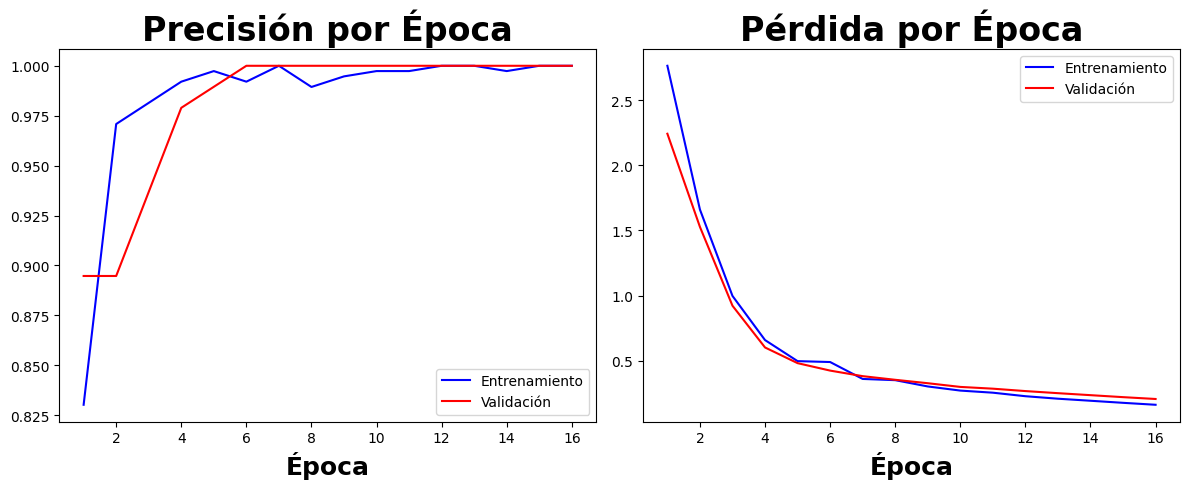

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 1.0000 - loss: 0.1652 - val_accuracy: 1.0000 - val_loss: 0.2071


In [ ]:
# Entrenar
history_binary = model_binary.fit(
    X_train_bin, y_train_bin,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop_binary, rt_plot_binary],
    verbose=1
)

In [ ]:
# Evaluar
loss_bin, accuracy_bin = model_binary.evaluate(X_test_bin, y_test_bin, verbose=0)
print(f"\nPrecisión en Test (Binaria): {accuracy_bin*100:.1f}%")


Precisión en Test (Binaria): 100.0%


In [ ]:
y_pred_bin = model_binary.predict(X_test_bin)
y_pred_bin_classes = (y_pred_bin > 0.5).astype(int)  # Umbral 0.5 para binaria

print("\nReporte de Clasificación (Binaria):")
print(classification_report(y_test_bin, y_pred_bin_classes, target_names=le_binary.classes_))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Reporte de Clasificación (Binaria):
                      precision    recall  f1-score   support

       Biblia Hebrea       1.00      1.00      1.00        22
Escrituras Asiáticas       1.00      1.00      1.00        96

            accuracy                           1.00       118
           macro avg       1.00      1.00      1.00       118
        weighted avg       1.00      1.00      1.00       118



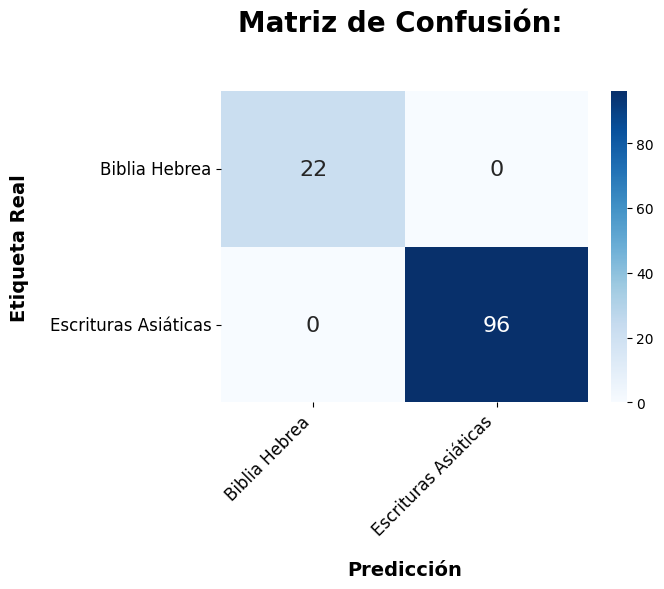

In [ ]:
# Matriz de confusión
plt.figure(figsize=(7, 6))
sns.heatmap(confusion_matrix(y_test_bin, y_pred_bin_classes), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_binary.classes_, yticklabels=le_binary.classes_,  annot_kws={"size": 16})
plt.xlabel('Predicción', fontsize=14, weight='bold', labelpad=15)
plt.ylabel('Etiqueta Real', fontsize=14, weight='bold', labelpad=15)
plt.title('Matriz de Confusión: \n', fontsize=20, weight='bold', pad=20)
plt.xticks(fontsize=12, rotation=45, ha='right')
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()